# 🍷 Tech Challenge — Classificação da Qualidade de Vinhos com Machine Learning

**POSTECH — Fase 2**

Este notebook desenvolve uma pipeline completa de classificação para prever se um vinho é de
**Alta Qualidade (nota ≥ 7)** ou **Baixa/Média Qualidade (nota < 7)** a partir de suas
características físico-químicas.

**Etapas:** (1) Compreensão do problema · (2) EDA · (3) Pré-processamento ·
(4) Modelagem · (5) Avaliação · (6) Interpretação.

**Dataset:** `WineQT.csv` (1.143 amostras de vinho tinto, 11 variáveis físico-químicas + nota de qualidade).

## 0. Imports e configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay
)
import warnings; warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Compreensão do Problema

A avaliação tradicional da qualidade do vinho depende de degustação por especialistas — um
processo **subjetivo, caro e demorado**. A proposta é usar dados físico-químicos coletados
durante a produção para prever a qualidade de forma objetiva, apoiando enólogos na tomada de decisão.

**Variável alvo:** a nota de qualidade (0–10) é transformada em uma classificação **binária**:
- `1` → **Alta Qualidade** (nota ≥ 7)
- `0` → **Baixa/Média Qualidade** (nota < 7)

In [2]:
df = pd.read_csv("../data/WineQT.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# a coluna 'id' é apenas um identificador, não é uma variável preditiva
if "id" in df.columns:
    df = df.drop(columns=["id"])

print("Shape:", df.shape)
df.head()

Shape: (1143, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df["target"] = (df["quality"] >= 7).astype(int)
features = [c for c in df.columns if c not in ["quality", "target"]]
print("Variáveis preditoras:", features)
df[["quality", "target"]].head()

Variáveis preditoras: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'ph', 'sulphates', 'alcohol']


,quality,target
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


## 2. Análise Exploratória de Dados (EDA)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1143 non-null   float64
 1   volatile_acidity      1143 non-null   float64
 2   citric_acid           1143 non-null   float64
 3   residual_sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free_sulfur_dioxide   1143 non-null   float64
 6   total_sulfur_dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   ph                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  target                1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile_acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric_acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual_sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free_sulfur_dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total_sulfur_dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
ph,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


### 2.1 Qualidade dos dados: faltantes e duplicados

In [6]:
print("Valores nulos:", df.isnull().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())

Valores nulos: 0
Linhas duplicadas: 125


> **Achado:** não há valores nulos. Aparecem **125 linhas duplicadas** após remover o `id`.
> No contexto de vinhos, amostras com medições idênticas podem ser vinhos diferentes que
> coincidem nos valores arredondados — por isso optamos por **mantê-las**, mas o fato fica registrado.

### 2.2 Distribuição da nota de qualidade (original)

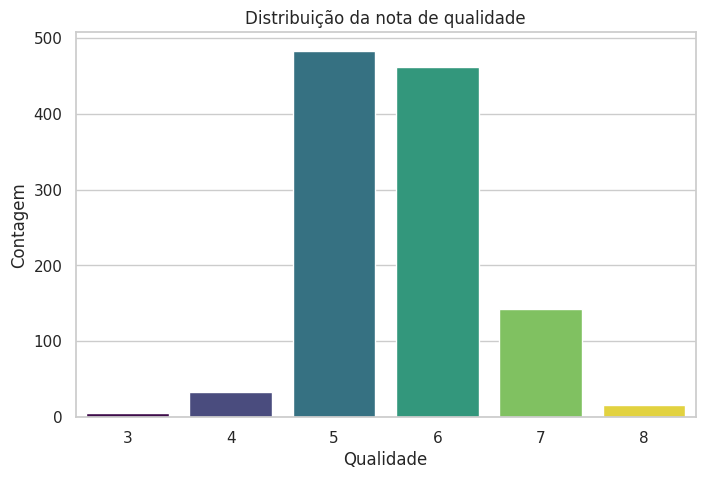

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [7]:
plt.figure()
sns.countplot(x="quality", data=df, hue="quality", palette="viridis", legend=False)
plt.title("Distribuição da nota de qualidade"); plt.xlabel("Qualidade"); plt.ylabel("Contagem")
plt.show()
print(df["quality"].value_counts().sort_index())

> A maioria das notas se concentra em **5 e 6**. Notas extremas (3, 4, 8) são raras.

### 2.3 Balanceamento das classes

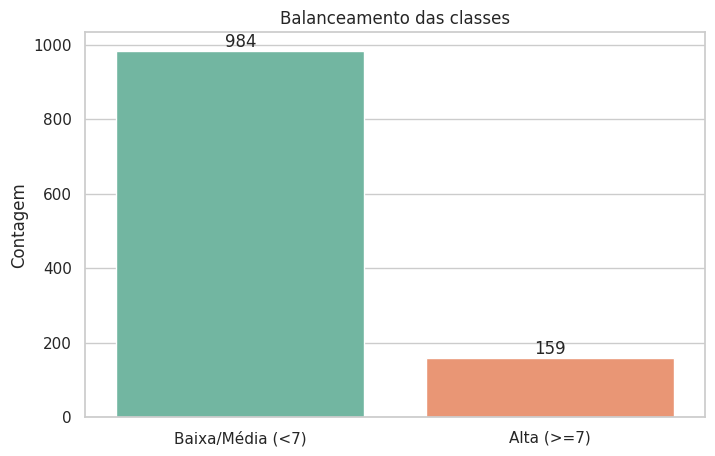

target
0    0.861
1    0.139
Name: proportion, dtype: float64


In [8]:
plt.figure()
ax = sns.countplot(x="target", data=df, hue="target", palette="Set2", legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["Baixa/Média (<7)", "Alta (>=7)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.title("Balanceamento das classes"); plt.xlabel(""); plt.ylabel("Contagem"); plt.show()
print(df["target"].value_counts(normalize=True).round(3))

> **Achado crítico:** apenas **~14%** das amostras são de Alta Qualidade (159 de 1.143).
> Esse **desbalanceamento** exige cuidado: a acurácia isolada é enganosa (um modelo que sempre
> prevê "Baixa/Média" já acertaria ~86%). Por isso priorizamos **F1 e ROC-AUC** e usamos
> `class_weight="balanced"` nos modelos.

### 2.4 Distribuição das variáveis físico-químicas

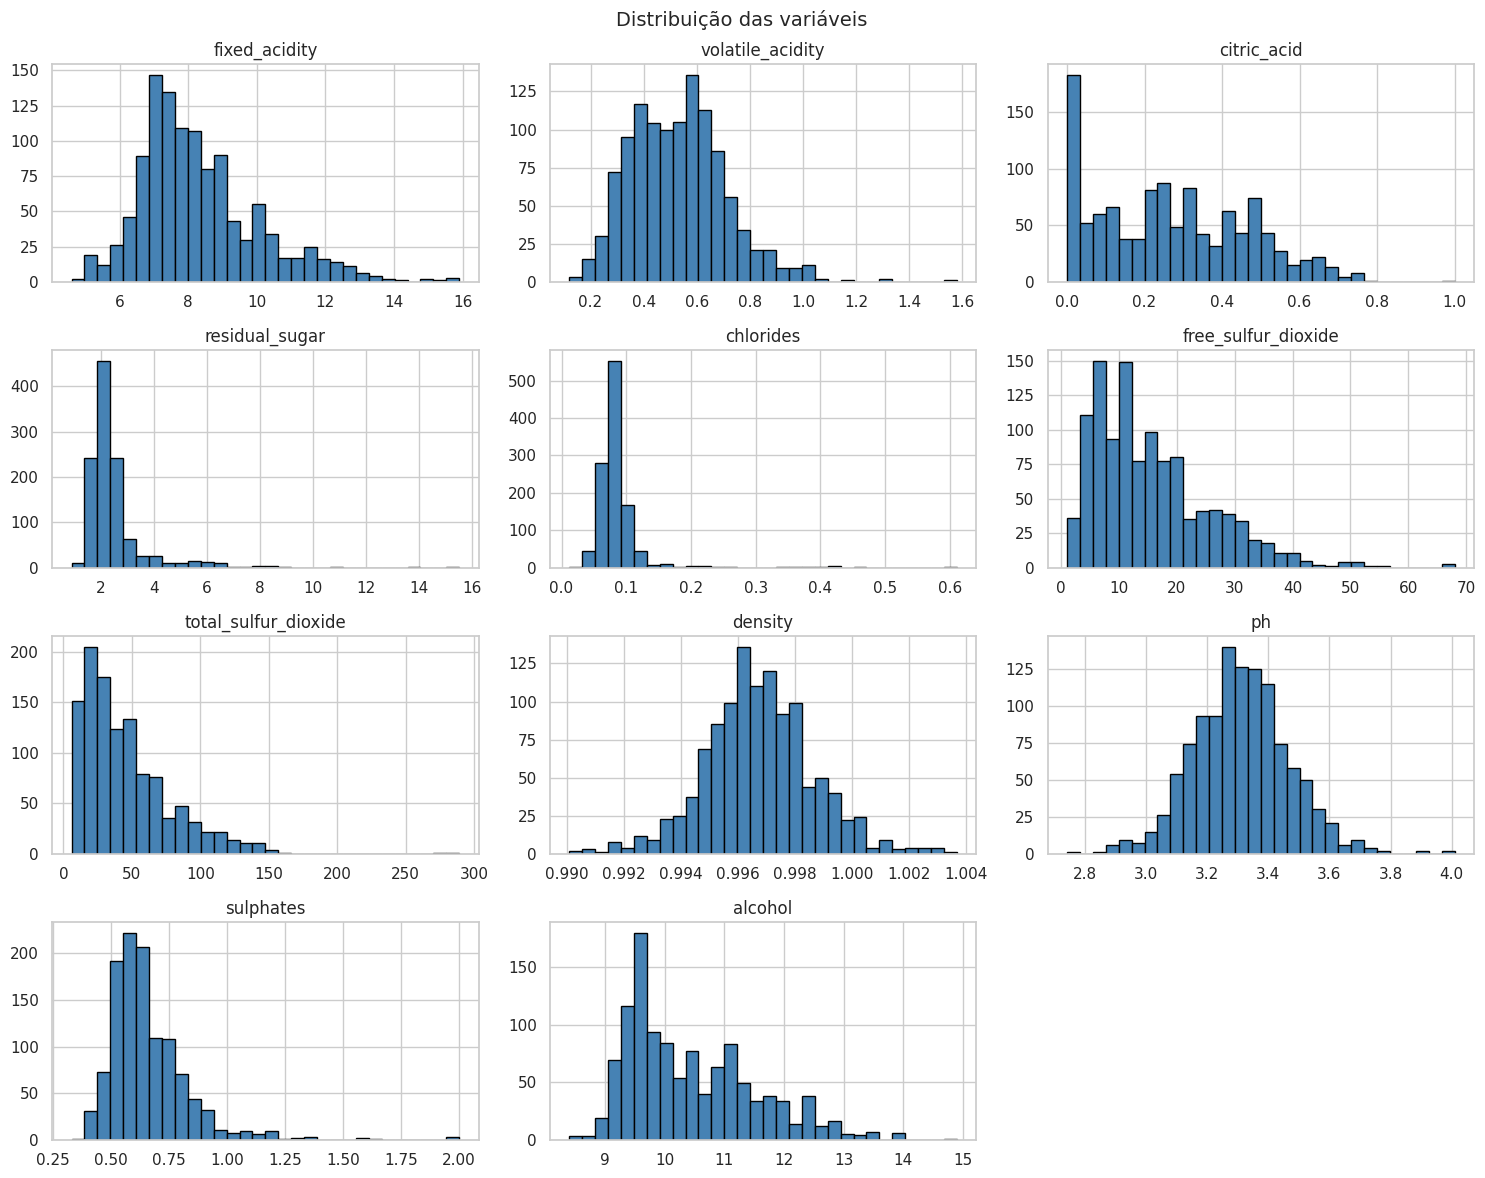

In [9]:
df[features].hist(bins=30, figsize=(15, 12), color="steelblue", edgecolor="black")
plt.suptitle("Distribuição das variáveis", fontsize=14); plt.tight_layout(); plt.show()

> Várias variáveis são **assimétricas à direita** (ex.: `residual_sugar`, `chlorides`,
> `sulphates`), com cauda longa de valores altos — o que antecipa a presença de outliers.

### 2.5 Correlações entre as variáveis

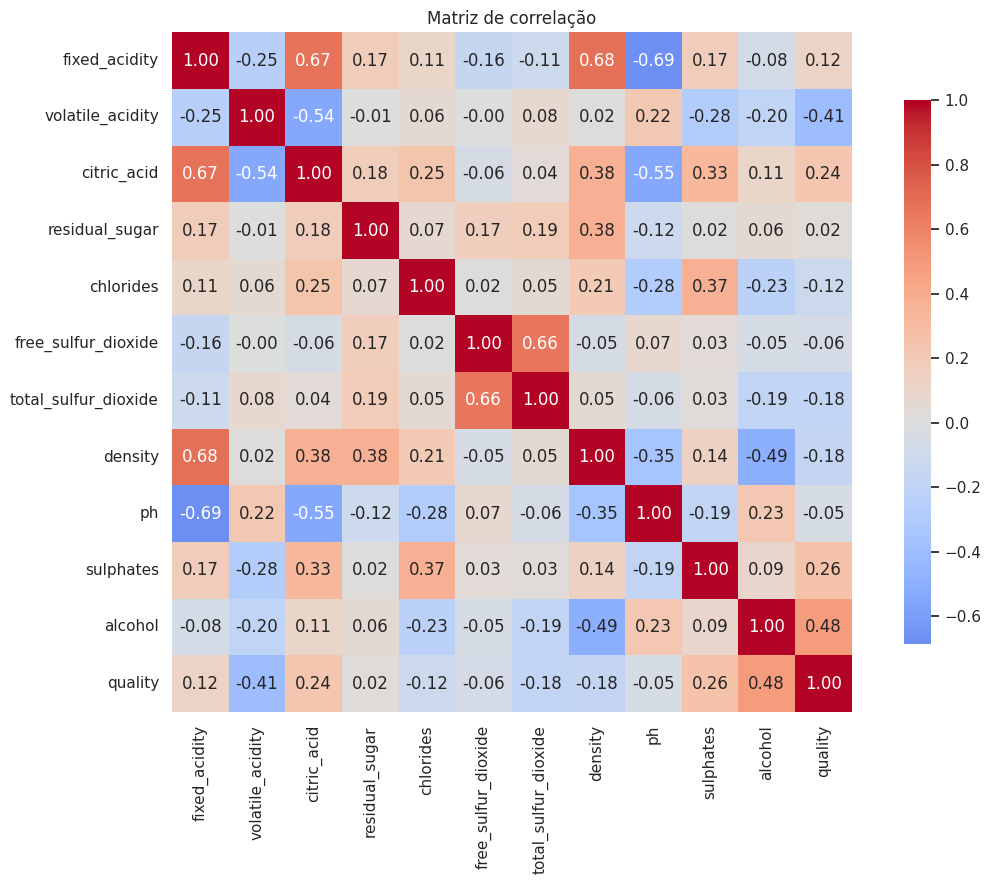

In [10]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[features + ["quality"]].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"shrink": .8})
plt.title("Matriz de correlação"); plt.tight_layout(); plt.show()

In [11]:
corr_quality = df[features].corrwith(df["quality"]).sort_values(ascending=False)
print("Correlação de cada variável com a qualidade:\n")
print(corr_quality)

Correlação de cada variável com a qualidade:

alcohol                 0.484866
sulphates               0.257710
citric_acid             0.240821
fixed_acidity           0.121970
residual_sugar          0.022002
ph                     -0.052453
free_sulfur_dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total_sulfur_dioxide   -0.183339
volatile_acidity       -0.407394
dtype: float64


**Justificativa das principais correlações com a qualidade:**

| Variável | Correlação | Interpretação |
|---|---|---|
| `alcohol` | **+0,48** | Maior correlação positiva: vinhos mais alcoólicos tendem a ser melhor avaliados (corpo e estrutura). |
| `sulphates` | +0,26 | Sulfatos atuam como conservantes/antioxidantes, ajudando a preservar a qualidade. |
| `citric_acid` | +0,24 | Adiciona frescor e sensação de "limpeza" ao sabor. |
| `volatile_acidity` | **−0,41** | Maior correlação negativa: acidez volátil alta gera aroma/sabor avinagrado (defeito). |
| `total_sulfur_dioxide` | −0,18 | Excesso de SO₂ pode trazer notas químicas indesejadas. |
| `density` | −0,18 | Densidade alta associa-se a menos álcool e mais açúcar residual. |

> Há também correlações **entre preditoras** (ex.: `fixed_acidity` × `density` × `citric_acid`),
> esperadas pela química do vinho — algo a considerar em modelos sensíveis a multicolinearidade.

### 2.6 As variáveis separam as classes? (médias por classe)

In [12]:
medias = df.groupby("target")[features].mean().T
medias.columns = ["Baixa/Média", "Alta"]
medias["dif_%"] = (100*(medias["Alta"]-medias["Baixa/Média"])/medias["Baixa/Média"]).round(1)
medias.round(3).sort_values("dif_%", ascending=False)

,Baixa/Média,Alta,dif_%
citric_acid,0.249,0.391,57.4
sulphates,0.643,0.746,15.9
alcohol,10.267,11.528,12.3
residual_sugar,2.497,2.748,10.1
fixed_acidity,8.225,8.847,7.6
density,0.997,0.996,-0.1
ph,3.316,3.282,-1.0
free_sulfur_dioxide,15.846,14.189,-10.5
chlorides,0.089,0.075,-16.0
total_sulfur_dioxide,47.408,36.673,-22.6


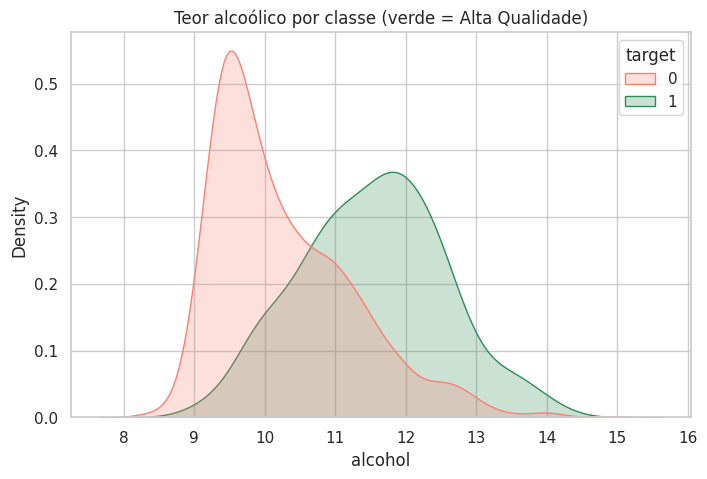

In [13]:
# visualizando o caso mais marcante: teor alcoólico
plt.figure()
sns.kdeplot(data=df, x="alcohol", hue="target", fill=True, common_norm=False,
            palette={0: "salmon", 1: "seagreen"})
plt.title("Teor alcoólico por classe (verde = Alta Qualidade)"); plt.show()

> Vinhos de Alta Qualidade têm, em média, **+12% de álcool**, **+57% de ácido cítrico**,
> **−29% de acidez volátil** e **−23% de SO₂ total**. Essas diferenças confirmam que as
> variáveis físico-químicas carregam sinal real para distinguir as classes.

### 2.7 Detecção de outliers (boxplots + regra do IQR)

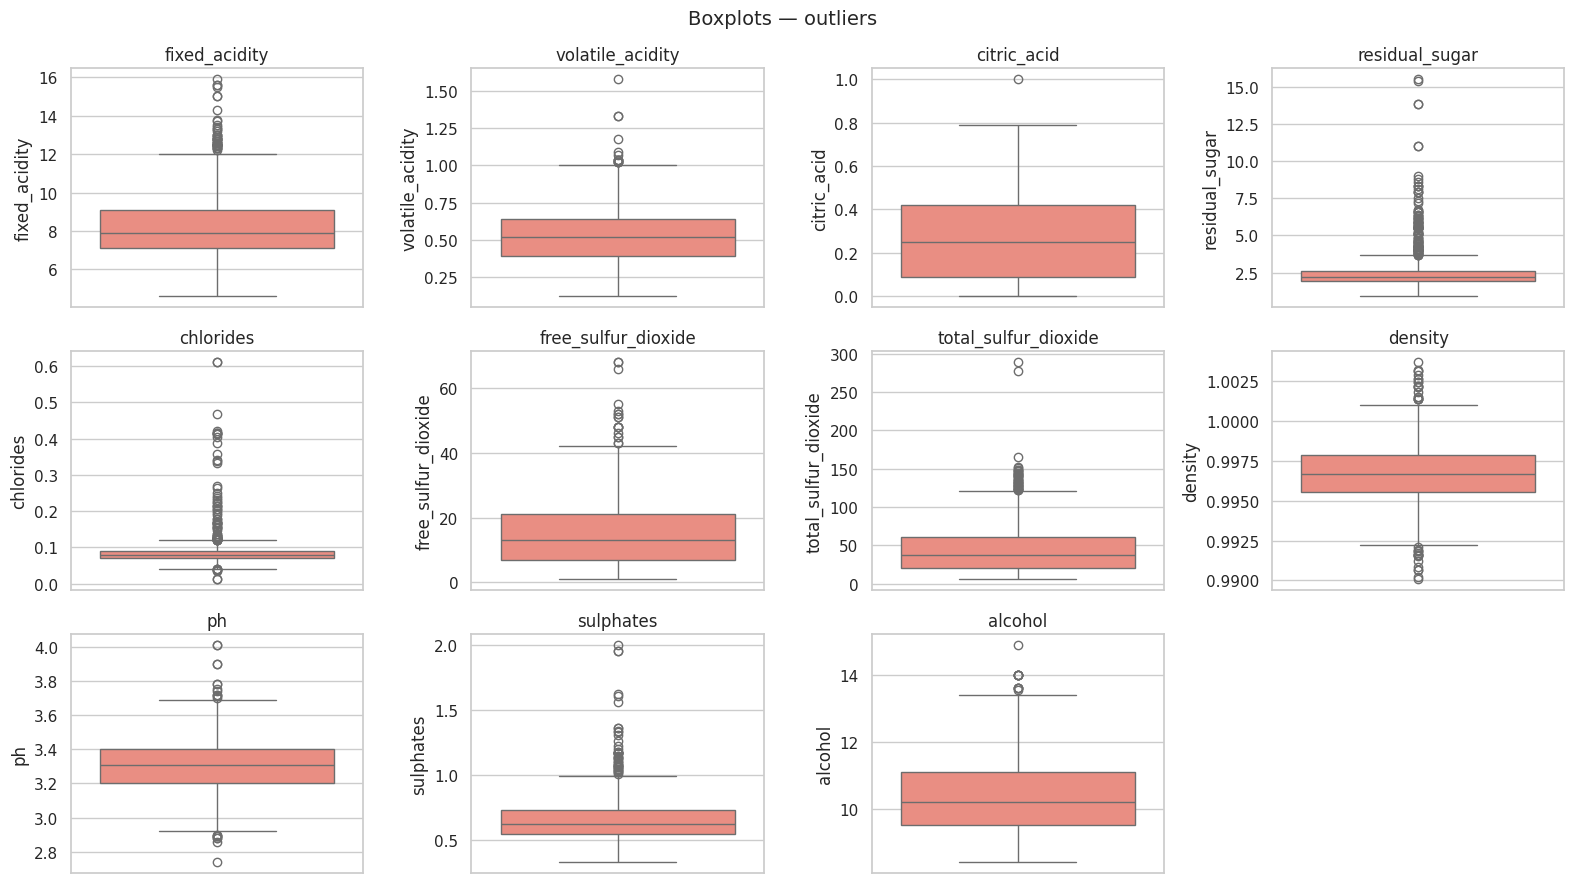

In [14]:
n = len(features); cols = 4; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, rows*3)); axes = axes.flatten()
for i, c in enumerate(features):
    sns.boxplot(y=df[c], ax=axes[i], color="salmon"); axes[i].set_title(c)
for j in range(i+1, len(axes)): fig.delaxes(axes[j])
plt.suptitle("Boxplots — outliers", fontsize=14); plt.tight_layout(); plt.show()

In [15]:
def outliers_iqr(s):
    q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3-q1
    return int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
pd.Series({c: outliers_iqr(df[c]) for c in features}).sort_values(ascending=False)

residual_sugar          110
chlorides                77
fixed_acidity            44
sulphates                43
total_sulfur_dioxide     40
density                  36
ph                       20
free_sulfur_dioxide      18
volatile_acidity         14
alcohol                  12
citric_acid               1
dtype: int64

> Há outliers em quase todas as variáveis, com destaque para `residual_sugar` (110) e
> `chlorides` (77). Eles parecem **valores extremos legítimos** (não erros de digitação), comuns
> em dados de produção. Optamos por **não removê-los**; em vez disso usamos modelos baseados em
> árvores (Random Forest, Gradient Boosting), que são **robustos a outliers**.

### 2.8 Verificação de consistência física dos valores

Além dos outliers estatísticos (regra do IQR), verificamos se os valores observados
respeitam faixas fisicamente plausíveis para vinho — isso ajuda a distinguir um
outlier legítimo (produção real, porém atípica) de um possível erro de medição/digitação.

In [ ]:
faixas_plausiveis = {
    "ph": (2.5, 4.5),
    "alcohol": (8.0, 15.0),
    "density": (0.98, 1.01),
    "volatile_acidity": (0.0, 2.0),
}
for col, (minimo, maximo) in faixas_plausiveis.items():
    fora = df[(df[col] < minimo) | (df[col] > maximo)]
    print(f"{col:20s}: {len(fora)} valor(es) fora da faixa plausível ({minimo}-{maximo})")

## 3. Pré-processamento

- **Faltantes:** não há (rotina de imputação por mediana deixada como salvaguarda).
- **Padronização:** aplicada via `StandardScaler` dentro de um `Pipeline` (evita vazamento de dados).
- **Split estratificado:** preserva a proporção de ~14% de Alta Qualidade em treino e teste.

### 3.1 Feature Engineering: novas variáveis são necessárias?

O enunciado sugere avaliar a criação de novas features "se considerado relevante".
Testamos abaixo duas combinações com fundamento químico simples:

- `acidez_total` = `fixed_acidity` + `volatile_acidity` (acidez total percebida no vinho);
- `alcool_densidade` = `alcohol` / `density` (combina os dois sinais mais fortes vistos na seção 2.5/2.6).

**Critério de decisão:** só incorporamos uma variável nova ao modelo final se ela apresentar
correlação com `quality` **claramente maior** do que as variáveis originais que a compõem —
caso contrário, mantemos o conjunto original por simplicidade e interpretabilidade
(relevante para comunicar o modelo a um público não técnico).

In [ ]:
df_fe = df.copy()
df_fe["acidez_total"] = df_fe["fixed_acidity"] + df_fe["volatile_acidity"]
df_fe["alcool_densidade"] = df_fe["alcohol"] / df_fe["density"]

novas_features = ["acidez_total", "alcool_densidade"]
print("Correlação das novas variáveis com a qualidade:")
print(df_fe[novas_features].corrwith(df_fe["quality"]), "\n")

print("Correlação das variáveis originais que as compõem (para comparação):")
print(corr_quality[["fixed_acidity", "volatile_acidity", "alcohol", "density"]])

> **Decisão:** as variáveis derivadas herdam majoritariamente o sinal das variáveis originais
> que as compõem (ver correlações acima) e não trazem ganho relevante frente a elas. Seguindo o
> critério definido na seção 3.1, **optamos por não incluir features engenheiradas no modelo
> final** — mantemos as 11 variáveis físico-químicas originais (`features`), o que preserva a
> simplicidade e a interpretabilidade do modelo para o público de negócio.

In [16]:
if df[features].isnull().sum().sum() > 0:
    df[features] = df[features].fillna(df[features].median())

X, y = df[features], df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporção de Alta no treino:", round(y_train.mean(), 3))

Treino: (914, 11) | Teste: (229, 11)
Proporção de Alta no treino: 0.139


> **Por que padronizar?** Modelos como Regressão Logística e SVM são sensíveis à escala das
> variáveis. Como `total_sulfur_dioxide` vai a dezenas e `density` fica perto de 1, sem
> padronização o modelo daria peso desproporcional às variáveis de maior magnitude.

## 4. Desenvolvimento de Modelos

Treinamos **quatro** modelos para comparação, cada um num `Pipeline` com `StandardScaler`.
Usamos `class_weight="balanced"` para compensar o desbalanceamento das classes.

In [17]:
modelos = {
    "Regressão Logística": Pipeline([("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Gradient Boosting": Pipeline([("scaler", StandardScaler()),
        ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
    "SVM (RBF)": Pipeline([("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))]),
}
for nome, m in modelos.items():
    m.fit(X_train, y_train); print(f"✓ {nome} treinado")

✓ Regressão Logística treinado


✓ Random Forest treinado


✓ Gradient Boosting treinado
✓ SVM (RBF) treinado


### 4.1 Validação cruzada (F1, 5 folds) no treino

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for nome, m in modelos.items():
    s = cross_val_score(m, X_train, y_train, cv=cv, scoring="f1")
    print(f"{nome:22s} | F1: {s.mean():.3f} (+/- {s.std():.3f})")

Regressão Logística    | F1: 0.505 (+/- 0.060)


Random Forest          | F1: 0.563 (+/- 0.061)


Gradient Boosting      | F1: 0.540 (+/- 0.089)


SVM (RBF)              | F1: 0.533 (+/- 0.032)


## 5. Avaliação dos Modelos (conjunto de teste)

**Métricas escolhidas e por quê:**
- **Acurácia:** referência, mas pouco confiável aqui (classes desbalanceadas).
- **Precisão:** dos vinhos que o modelo chamou de "Alta", quantos eram de fato.
- **Recall:** dos vinhos de Alta de verdade, quantos o modelo encontrou.
- **F1:** equilíbrio entre precisão e recall — **métrica principal** neste problema.
- **ROC-AUC:** capacidade de separar as classes independente do limiar.

In [19]:
def avaliar(nome, m):
    yp = m.predict(X_test); pr = m.predict_proba(X_test)[:, 1]
    return {"Modelo": nome,
            "Acurácia": accuracy_score(y_test, yp),
            "Precisão": precision_score(y_test, yp),
            "Recall": recall_score(y_test, yp),
            "F1": f1_score(y_test, yp),
            "ROC-AUC": roc_auc_score(y_test, pr)}
df_res = pd.DataFrame([avaliar(n, m) for n, m in modelos.items()]).set_index("Modelo")
df_res.round(3).sort_values("F1", ascending=False)

,Acurácia,Precisão,Recall,F1,ROC-AUC
Modelo,,,,,
Random Forest,0.913,0.800,0.500,0.615,0.910
Gradient Boosting,0.900,0.667,0.562,0.610,0.879
SVM (RBF),0.817,0.411,0.719,0.523,0.870
Regressão Logística,0.799,0.379,0.688,0.489,0.850


### 5.1 Relatório de classificação por modelo

In [20]:
for nome, m in modelos.items():
    print("="*60); print(nome); print("="*60)
    print(classification_report(y_test, m.predict(X_test), target_names=["Baixa/Média", "Alta"]))

Regressão Logística
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.82      0.88       197
        Alta       0.38      0.69      0.49        32

    accuracy                           0.80       229
   macro avg       0.66      0.75      0.68       229
weighted avg       0.86      0.80      0.82       229

Random Forest
              precision    recall  f1-score   support

 Baixa/Média       0.92      0.98      0.95       197
        Alta       0.80      0.50      0.62        32

    accuracy                           0.91       229
   macro avg       0.86      0.74      0.78       229
weighted avg       0.91      0.91      0.90       229

Gradient Boosting
              precision    recall  f1-score   support

 Baixa/Média       0.93      0.95      0.94       197
        Alta       0.67      0.56      0.61        32

    accuracy                           0.90       229
   macro avg       0.80      0.76      0.78       229
weighted avg       0.8

### 5.2 Matrizes de confusão

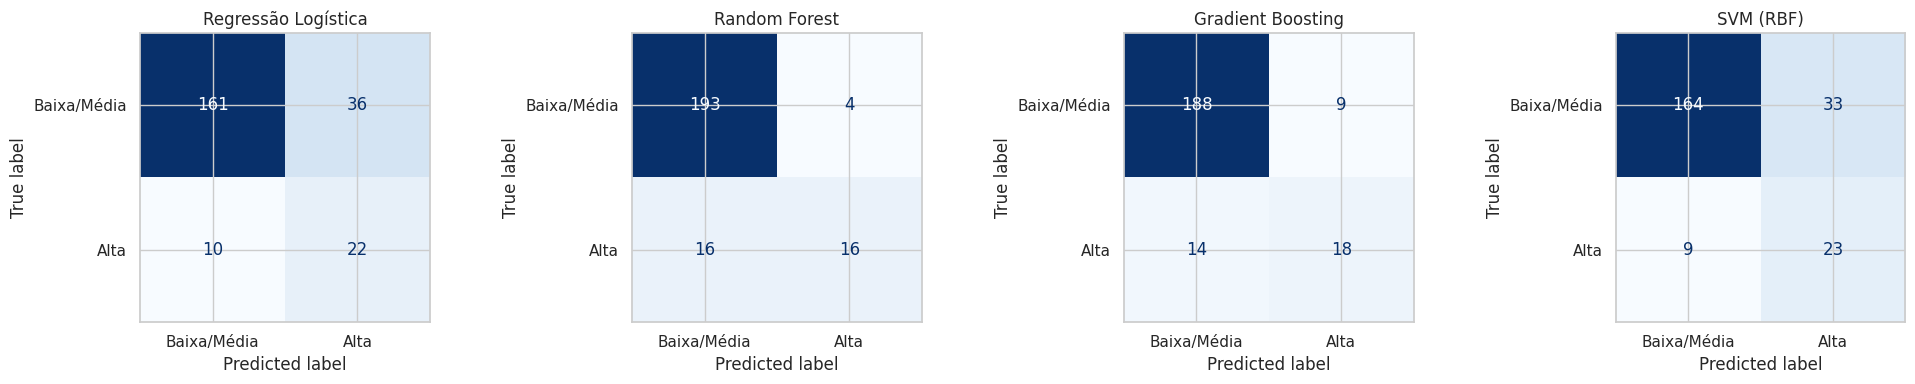

In [21]:
fig, axes = plt.subplots(1, len(modelos), figsize=(5*len(modelos), 4))
for ax, (nome, m) in zip(axes, modelos.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, m.predict(X_test)),
        display_labels=["Baixa/Média", "Alta"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)
plt.tight_layout(); plt.show()

### 5.3 Curvas ROC

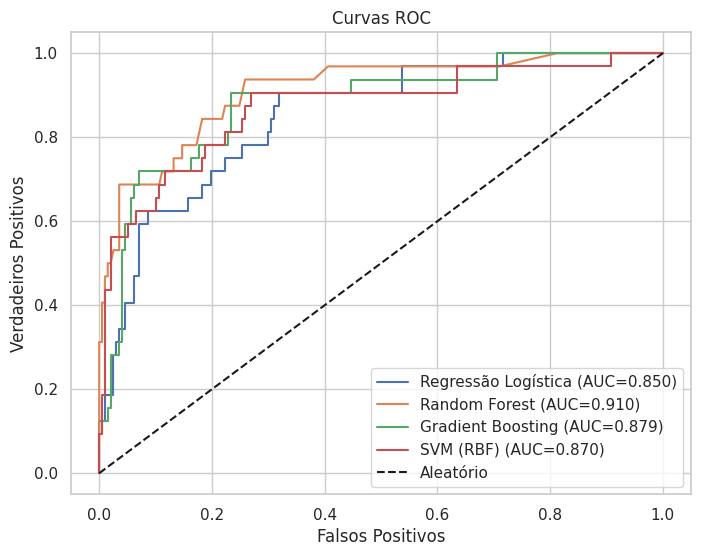

In [22]:
plt.figure(figsize=(8, 6))
for nome, m in modelos.items():
    pr = m.predict_proba(X_test)[:, 1]; fpr, tpr, _ = roc_curve(y_test, pr)
    plt.plot(fpr, tpr, label=f"{nome} (AUC={roc_auc_score(y_test, pr):.3f})")
plt.plot([0,1],[0,1],"k--", label="Aleatório")
plt.xlabel("Falsos Positivos"); plt.ylabel("Verdadeiros Positivos")
plt.title("Curvas ROC"); plt.legend(loc="lower right"); plt.show()

> **Comparação:** o **Random Forest** obteve o melhor F1 (~0,62) e o melhor ROC-AUC (~0,91),
> combinando alta precisão com recall razoável. A Regressão Logística e o SVM atingem recall maior
> (encontram mais vinhos de Alta), mas ao custo de muitos falsos positivos (precisão baixa). O
> **Gradient Boosting** ficou muito próximo do Random Forest e é uma segunda escolha sólida.

### 5.4 Leitura de negócio: o custo dos erros não é simétrico

Antes de declarar um "modelo vencedor" apenas pelas métricas, vale traduzir os dois tipos de
erro para a operação:

- **Falso Positivo** (rotular um vinho comum como Alta Qualidade): risco de precificar ou
  divulgar como "premium" um produto que não sustenta essa reputação.
- **Falso Negativo** (deixar passar um vinho realmente de Alta Qualidade): oportunidade
  perdida — um lote de excelência pode ser vendido/tratado como padrão.

Se a empresa considerar mais custoso **perder um vinho bom** (Falso Negativo), faz sentido
priorizar **recall** mesmo abrindo mão de precisão — o que favoreceria SVM ou Regressão
Logística (recall ≈ 0,70-0,72) em vez do Random Forest (recall = 0,50). Se o custo maior
estiver em **classificar errado** (ex.: contratos com preço atrelado ao rótulo de qualidade),
a maior precisão do Random Forest (0,80) é preferível. Ou seja, a escolha do "melhor modelo"
não é puramente estatística — depende de qual erro a operação está mais disposta a tolerar.

### 5.5 Ajuste de limiar (threshold) do Random Forest

Por padrão, todo classificador binário usa limiar 0,5 (probabilidade ≥ 50% → "Alta Qualidade").
Esse valor é uma convenção, não uma regra de negócio. Como visto na seção 5.4, se o custo de
**perder um vinho bom** for maior do que o custo de **rotular um vinho comum como especial**,
faz sentido reduzir o limiar do Random Forest para capturar mais casos de Alta Qualidade —
mesmo que isso reduza um pouco a precisão.

In [ ]:
from sklearn.metrics import precision_recall_curve

rf_model = modelos["Random Forest"]
probs_rf = rf_model.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, probs_rf)

plt.figure()
plt.plot(thresholds, prec[:-1], label="Precisão")
plt.plot(thresholds, rec[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="Limiar padrão (0,5)")
plt.xlabel("Limiar de decisão"); plt.ylabel("Score")
plt.title("Precisão e Recall por limiar — Random Forest")
plt.legend(); plt.show()

print(f"{'Limiar':>8} | {'Precisão':>9} | {'Recall':>7} | {'F1':>6}")
for limiar in [0.5, 0.4, 0.3, 0.2]:
    yp_l = (probs_rf >= limiar).astype(int)
    print(f"{limiar:>8.1f} | {precision_score(y_test, yp_l):>9.3f} | "
          f"{recall_score(y_test, yp_l):>7.3f} | {f1_score(y_test, yp_l):>6.3f}")

> **Leitura do gráfico e da tabela:** reduzir o limiar sempre aumenta o recall (mais vinhos bons
> são capturados) e reduz a precisão (mais falsos positivos) — é o trade-off inerente à
> classificação por probabilidade. Observando os valores acima, a área de negócio pode escolher
> o ponto de operação mais alinhado à sua tolerância a erro, em vez de aceitar o limiar padrão de
> 0,5 por padrão da biblioteca. Essa é uma decisão de **negócio**, não apenas técnica.

## 6. Interpretação dos Resultados

### 6.1 Importância das variáveis (Random Forest)

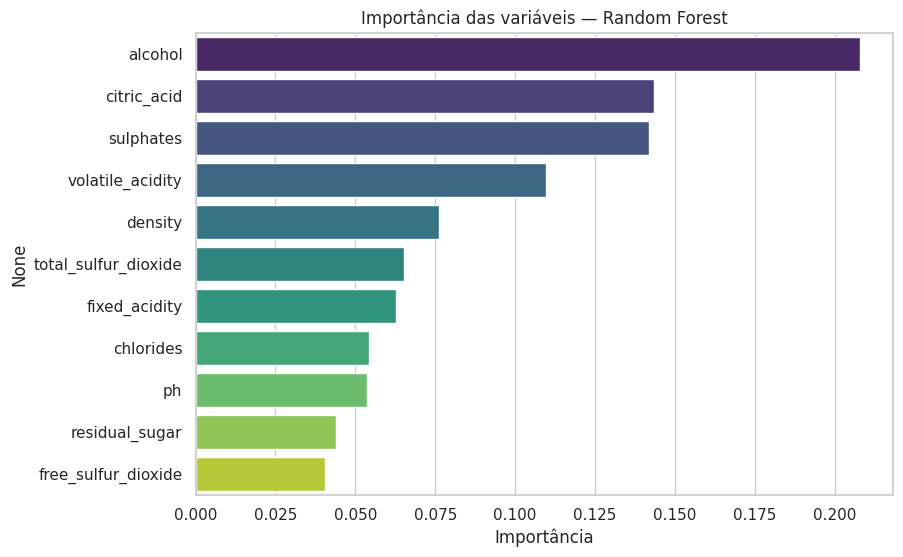

alcohol                 0.207930
citric_acid             0.143539
sulphates               0.142066
volatile_acidity        0.109646
density                 0.076331
total_sulfur_dioxide    0.065355
fixed_acidity           0.062671
chlorides               0.054218
ph                      0.053538
residual_sugar          0.044083
free_sulfur_dioxide     0.040624
dtype: float64

In [23]:
rf = modelos["Random Forest"].named_steps["clf"]
imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette="viridis", legend=False)
plt.title("Importância das variáveis — Random Forest"); plt.xlabel("Importância"); plt.show()
imp

### 6.2 Coeficientes (Regressão Logística) — direção do efeito

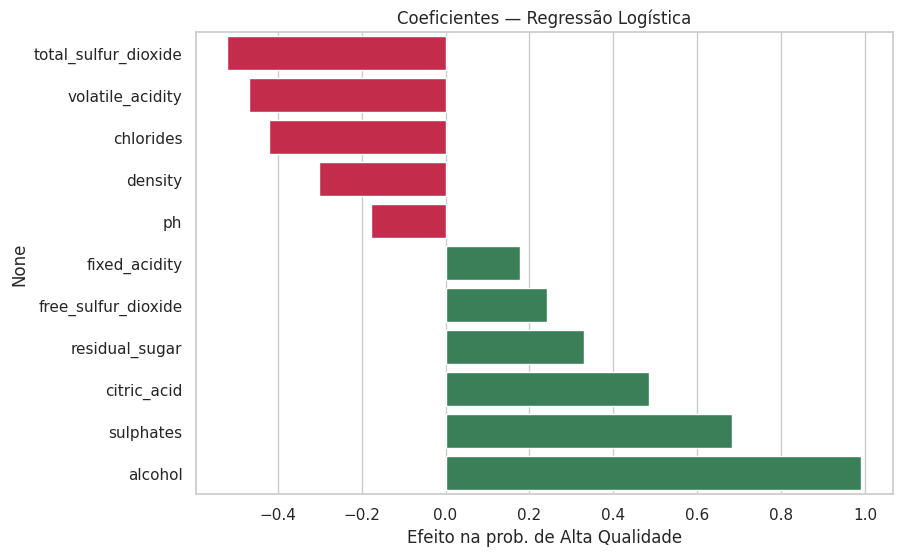

alcohol                 0.991160
sulphates               0.682432
citric_acid             0.485925
residual_sugar          0.329107
free_sulfur_dioxide     0.242067
fixed_acidity           0.177371
ph                     -0.177341
density                -0.301383
chlorides              -0.420729
volatile_acidity       -0.467282
total_sulfur_dioxide   -0.519930
dtype: float64

In [24]:
logreg = modelos["Regressão Logística"].named_steps["clf"]
coefs = pd.Series(logreg.coef_[0], index=features).sort_values()
plt.figure(figsize=(9, 6))
colors = ["crimson" if c < 0 else "seagreen" for c in coefs.values]
sns.barplot(x=coefs.values, y=coefs.index, hue=coefs.index, palette=colors, legend=False)
plt.title("Coeficientes — Regressão Logística"); plt.xlabel("Efeito na prob. de Alta Qualidade"); plt.show()
coefs.sort_values(ascending=False)

### 6.3 Conclusões e implicações para a produção

**Variáveis mais influentes na qualidade:**
1. **Teor alcoólico (`alcohol`)** — fator nº 1 em importância e o de maior correlação positiva.
2. **Ácido cítrico (`citric_acid`)** e **sulfatos (`sulphates`)** — contribuem positivamente (frescor e conservação).
3. **Acidez volátil (`volatile_acidity`)** — principal fator **negativo**: quanto maior, pior a avaliação.

**Implicações práticas para enólogos e produtores:**
- **Controlar a acidez volátil** é a alavanca mais clara de qualidade — monitorar fermentação e
  higiene para evitar a formação de ácido acético (aroma avinagrado).
- **Favorecer maturação adequada das uvas** (mais açúcar → mais álcool potencial) tende a elevar a qualidade.
- **Ajustar sulfatos e ácido cítrico** dentro dos limites enológicos pode melhorar conservação e frescor.

**Modelo recomendado:** **Random Forest** — melhor F1 e ROC-AUC, robusto a outliers e capaz de
capturar relações não-lineares entre as variáveis. Como discutido na seção 5.4, essa recomendação
vale para um cenário em que evitar falsos positivos é a prioridade; se a prioridade de negócio for
não perder vinhos bons, o limiar ajustado (seção 5.5) ou os modelos com maior recall (SVM/Regressão
Logística) são alternativas mais adequadas.

**Limitações:**
- Base **desbalanceada** (~14% Alta) — recall da classe Alta ainda tem espaço para melhora
  (técnicas como SMOTE ou ajuste de limiar podem ser exploradas).
- A nota de qualidade vem de **avaliação sensorial humana**, naturalmente subjetiva.
- Dataset restrito a **vinho tinto**; generalização para outros tipos exige novos dados.

**Próximos passos:**
- Testar **SMOTE/oversampling** e o **ajuste de limiar** (seção 5.5) para elevar o recall sem
  sacrificar tanto a precisão.
- Buscar dados com **múltiplas avaliações sensoriais por amostra** para reduzir o efeito da
  subjetividade na variável alvo.
- Expandir a análise para **vinho branco** e validar se os mesmos fatores (álcool, acidez
  volátil) se mantêm relevantes.
- Explorar **ajuste de hiperparâmetros** (ex.: `GridSearchCV`) nos dois modelos com melhor
  desempenho (Random Forest e Gradient Boosting) para tentar ganhos adicionais de F1.